Most Optimal Skills to learn for Data Analysts

Methodology
1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

In [13]:
#Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Datasets
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [17]:
#filter for the job titles and country
df_DA_US= df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()


In [18]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [24]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent] 

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


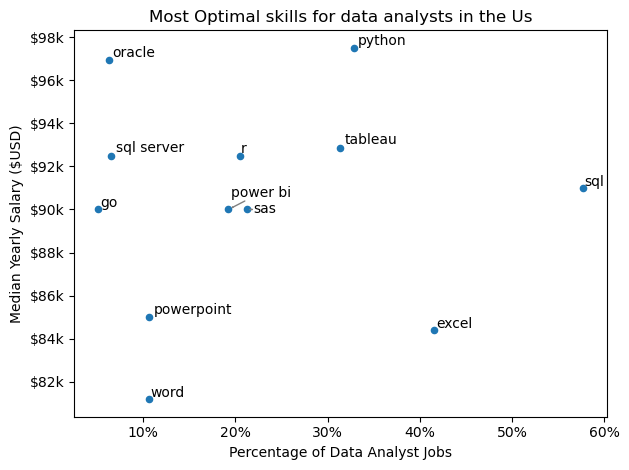

In [30]:
from adjustText import adjust_text

# fig, ax = plt.subplots()

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary')
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))
    
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))


#Set axis labels, title and legend
plt.title('Most Optimal skills for data analysts in the Us')
plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')

#Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [31]:
df['job_type_skills'].head(10)

0                                                 None
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

Coloring by Technology

In [32]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['excel',
  'looker',
  'qlik',
  'tableau',
  'outlook',
  'ssrs',
  'sheets',
  'esquisse',
  'dax',
  'alteryx',
  'word',
  'power bi',
  'msaccess',
  'cognos',
  'ssis',
  'sas',
  'spss',
  'microstrategy',
  'powerbi',
  'powerpoint',
  'sap',
  'ms access',
  'nuix',
  'spreadsheet',
  'sharepoint',
  'splunk',
  'visio',
  'datarobot'],
 'programming': ['bash',
  'golang',
  'solidity',
  'visual basic',
  'no-sql',
  'f#',
  'r',
  'elixir',
  'dart',
  'clojure',
  'erlang',
  'rust',
  'c#',
  'vba',
  'go',
  't-sql',
  'pascal',
  'c',
  'swift',
  'mongo',
  'apl',
  'nosql',
  'julia',
  'php',
  'shell',
  'css',
  'java',
  'sas',
  'perl',
  'html',
  'ruby',
  'python',
  'mongodb',
  'lua',
  'scala',
  'vb.net',
  'objective-c',
  'haskell',
  'visualbasic',
  'assembly',
  'matlab',
  'typescript',
  'sass',
  'ocaml',
  'javascript',
  'crystal',
  'c++',
  'fortran',
  'lisp',
  'delphi',
  'sql',
  'groovy',
  'kotlin',
  'cobol',
  'powersh

In [39]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,excel
0,analyst_tools,looker
0,analyst_tools,qlik
0,analyst_tools,tableau
0,analyst_tools,outlook
...,...,...
9,sync,webex
9,sync,symphony
9,sync,twilio
9,sync,unify


In [41]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

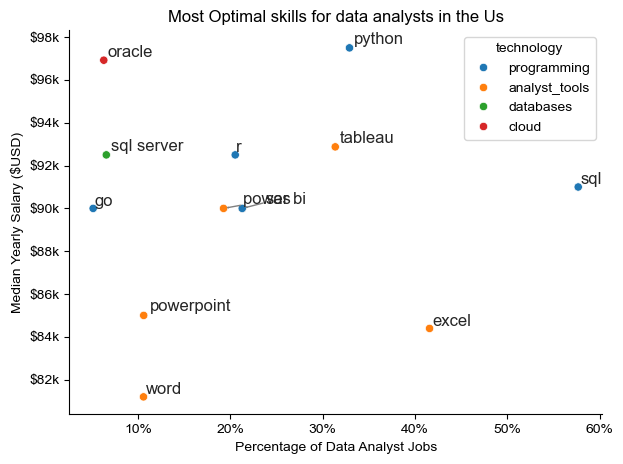

In [43]:
from adjustText import adjust_text

# fig, ax = plt.subplots()

# df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

#Prepare text for adjust text
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))
    
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=1))

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))


#Set axis labels, title and legend
plt.title('Most Optimal skills for data analysts in the Us')
plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')

#Adjust layout and display the plot
plt.tight_layout()
plt.show()